TITANIC_SURVIVAL_PREDICTION

In [1]:
import pandas as pd
import joblib

In [2]:
file_path="C:/Users/ADHITHYA/OneDrive/Documents/Shristi/AI ML/titanic.csv"

In [3]:
df=pd.read_csv(file_path)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [7]:
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])

In [8]:
df.duplicated().value_counts()

False    891
Name: count, dtype: int64

In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])

In [11]:
df['Embarked']=le.fit_transform(df['Embarked'])

In [12]:
df=df.drop(columns=['PassengerId','Name','Fare','Ticket','Cabin'])

In [13]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,1,22.0,1,0,2
1,1,1,0,38.0,1,0,0
2,1,3,0,26.0,0,0,2
3,1,1,0,35.0,1,0,2
4,0,3,1,35.0,0,0,2


In [14]:
df.shape

(891, 7)

In [15]:
x=df.drop('Survived',axis=1)
y=df['Survived']

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
log_reg=LogisticRegression()
log_reg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import accuracy_score,classification_report
y_pred_log=log_reg.predict(x_test)
print("\nLogistic Regression Results")
print("Accuracy :",accuracy_score(y_test,y_pred_log))
print(classification_report(y_test,y_pred_log,target_names=["Survived","Not Survived"]))


Logistic Regression Results
Accuracy : 0.8097014925373134
              precision    recall  f1-score   support

    Survived       0.82      0.87      0.84       157
Not Survived       0.79      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



In [21]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

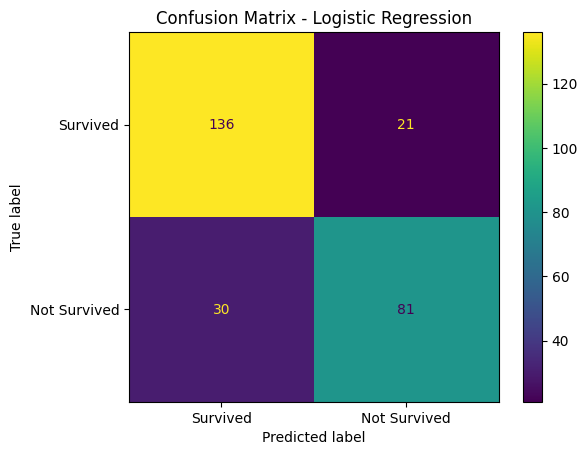

In [22]:
cm=confusion_matrix(y_test,y_pred_log)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Survived","Not Survived"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [23]:
new_data=[[2,0,44.0,1,0,1]]
new_data_df=pd.DataFrame(new_data,columns=x.columns)
log_result=log_reg.predict(new_data_df)[0]

if log_result == 1:
    print("Logistic Regression: Survived")
else:
    print("Logistic Regression: Not Survived")

Logistic Regression: Survived


In [24]:
joblib.dump(log_reg, "logistic_model.pkl")
joblib.dump(log_reg, "logistic_model.joblib")

print("Model Saved Successfully")

Model Saved Successfully
